In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import torch
from typing import Optional, Type
import torch.nn as nn
from skimage import filters
import numpy as np

class FromNumpyToTensor(nn.Module):
    """
    Converts numpy.ndarray, with shape [C] x H x W, to torch.Tensor, while preserving dtype.
    If channels dimension is not present it is added to tensor as the first dimension.
    """
    def forward(self, x: np.ndarray) -> torch.Tensor:
        x = torch.from_numpy(x)
        if len(x.shape) == 2:
            x = x.unsqueeze(0)
        return x


class ArcsinhNormalize(nn.Module):
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.arcsinh(x / 5)


class MinMaxNormalize(nn.Module):
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return (x - x.amin(dim=[1, 2], keepdim=True)) / x.amax(dim=[1, 2], keepdim=True)
    
class ButterworthFilter(nn.Module):
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        assert len(x.shape) == 3, f'Incorrect shape {x.shape}'
        x = x.numpy()
        for i in range(x.shape[0]):
            x[i] = filters.butterworth(
                        x[i],
                        cutoff_frequency_ratio=0.2,
                        order=3.0,
                        high_pass=False,
                        squared_butterworth=True,
                        npad=0,
                    )
        x = torch.from_numpy(x)
        return x


class GlobalNormalize(nn.Module):
    # Clip everything to [0, 3] and divide by 3
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.clamp(x, 0, 3) / 3


class GlobalResponseNormalization(nn.Module):
    """Global Response Normalization (GRN) layer 
    from https://arxiv.org/pdf/2301.00808"""

    def __init__(self, dim, eps: float = 1e-6):
        super().__init__()
        self.eps = eps

        self.gamma = nn.Parameter(torch.zeros(1, 1, 1, dim))
        self.beta = nn.Parameter(torch.zeros(1, 1, 1, dim))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # B, H, W, E = x.shape

        gx = torch.norm(x, p=2, dim=(1,2), keepdim=True)
        nx = gx / (gx.mean(dim=-1, keepdim=True) + self.eps)
        return self.gamma * (x * nx) + self.beta + x

class ConvNextBlock(nn.Module):
    """ConvNext2 block"""
    def __init__(
            self,
            dim: int,
            inter_dim: int = None,
            kernel_size: int = 7,
            padding: int = 3,
    ):
            super().__init__()
            inter_dim = inter_dim or dim * 4
            self.conv1 = nn.Conv2d(dim, dim, kernel_size=kernel_size, padding=padding, groups=dim)
            self.ln = nn.LayerNorm(dim)
            self.conv2 = nn.Linear(dim, inter_dim) # equivalent to nn.Conv2d(dim, inter_dim, kernel_size=1)
            self.act = nn.GELU()
            self.grn = GlobalResponseNormalization(inter_dim)
            self.conv3 = nn.Linear(inter_dim, dim) # equivalent to nn.Conv2d(inter_dim, dim, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # B, C, H, W = x.shape
        residual = x
        x = self.conv1(x)
        x = x.permute(0, 2, 3, 1)  # [B, H, W, C]
        x = self.ln(x)
        x = self.conv2(x)
        x = self.act(x)
        x = self.grn(x)
        x = self.conv3(x)
        x = x.permute(0, 3, 1, 2) # [B, C, H, W]
        x = x + residual

        return x

class MultiplexImageDecoder(nn.Module):
    """Decoder for restoring the multiplex image from the embedding tensor."""
    
    def __init__(
            self,
            input_embedding_dim: int,
            decoded_embed_dim: int,
            num_blocks: int,
            scaling_factor: int,
            num_channels: int,
            decoder_layer_type: Optional[Type] = ConvNextBlock,
            **kwargs
        ) -> None:
            """
            Args:
                input_embedding_dim (int): Embedding dimension of the input tensor.
                decoded_embed_dim (int): Embedding dimension of the decoded tensor (before last projections).
                num_blocks (int): Number of multiplex blocks in each intermediate layer.
                scaling_factor (int): Scaling factor for the upsampling.
                num_channels (int): Number of possible output channels/markers.
                decoder_layer_type (Type, optional): Type of the decoder layer. Defaults to ConvNextBlock.
            """
            super().__init__()
            self.scaling_factor = scaling_factor
            self.num_channels = num_channels
            self.decoded_embed_dim = decoded_embed_dim
            self.num_outputs = 2

            self.channel_embed = nn.Embedding(num_channels, input_embedding_dim * decoded_embed_dim) # input projection
            self.channel_biases = nn.Embedding(num_channels, decoded_embed_dim)

            self.decoder = nn.Sequential(*[
                decoder_layer_type(
                    decoded_embed_dim, 
                    **kwargs
                ) for _ in range(num_blocks)
            ])
            self.pred = nn.Conv2d(
                decoded_embed_dim, 
                scaling_factor**2 * self.num_outputs, 
                kernel_size=1
            )

    def forward(self, x: torch.Tensor, indices: torch.Tensor) -> torch.Tensor:
        """Forward pass of the Multiplex Image Decoder.

        Args:
            x (torch.Tensor): Input tensor (embedding).
            indices (torch.Tensor): Indices of the markers.

        Returns:
            torch.Tensor: Reconstructed image tensor
        """
        B, I, H, W = x.shape
        E, A, O = self.decoded_embed_dim, self.scaling_factor, self.num_outputs

        channel_embeds = self.channel_embed(indices) # [B, C, I*E]
        channel_biases = self.channel_biases(indices) # [B, C, E]
        C = channel_embeds.shape[1]
        N = B * C
        channel_embeds = channel_embeds.reshape(B, C, I, E)
        channel_biases = channel_biases.reshape(B, C, E, 1, 1)

        x = torch.einsum('bihw, bcie -> bcehw', x, channel_embeds)
        x += channel_biases
        x = x.reshape(N, E, H, W)

        x = self.decoder(x)
        x = self.pred(x)

        x = x.reshape(N, A, A, O, H, W).reshape(B, C, A, A, O, H, W)
        x = torch.einsum('bcxyohw -> bchxwyo', x)

        x = x.reshape(B, C, H*A, W*A, O)

        return x
    

In [2]:
import pickle
with open("/raid/tnocon/data/IMC/test.pkl", 'rb') as f:
    embeddings = pickle.load(f)

In [3]:
import yaml  # this is PyYAML

with open("/raid/immucan/szlukasik_embeddings/decoder_config.yaml", "r") as f:
    decoder_config = yaml.safe_load(f)  

In [4]:
decoder = MultiplexImageDecoder(**decoder_config)

In [5]:
import torch
decoder_state_dict = torch.load("/raid/immucan/szlukasik_embeddings/checkpoint-EquivariantConvnext_20250821_022303_J1444-epoch_79-decoder.pth", map_location='cpu')
decoder.load_state_dict(decoder_state_dict)

<All keys matched successfully>

In [6]:
decoder = decoder.to('cuda:0')

In [7]:
import os
import rootutils

rootutils.setup_root(os.getcwd(), indicator=".project-root", pythonpath=True)

from torchvision import transforms
import torch
from src.data.components.graphs_datamodules import (
    IMCBaseDictTransform,
    PickleDataset,
    PatchAugmentations,
)
from src.data.imc_datamodule import add_channel
import src.data.components.graphs_datamodules as gd
from torchvision.datasets import MNIST
from torch.utils.data import ConcatDataset, Dataset, random_split

In [8]:
from pathlib import Path
import pickle

In [10]:
import copy

embeddings_copy = copy.deepcopy(embeddings)
transform = IMCBaseDictTransform()
out = transform(embeddings_copy[0])

In [11]:
recovered = out['r0_nf'].T.view(512, 13, 13)

In [12]:
torch.allclose(recovered, torch.from_numpy(embeddings[0]['r0_nf']))

True

In [13]:
def apply_transform(grid: torch.Tensor, key: str) -> torch.Tensor:
        """
        Apply rotation/flip based on key string (e.g. 'r90_f').
        """
        # Parse
        rot_part, flip_part = key.split("_")
        angle = int(rot_part[1:])  # 'r90' -> 90
        flip = flip_part == "f"

        # Apply rotation
        k = angle // 90
        out = torch.rot90(grid, k=-k, dims=[0, 1]) if k > 0 else grid

        # Apply flip
        if flip:
            out = torch.flip(out, dims=[-1])

        return out

def make_grid(num_nodes_per_dim: int) -> torch.Tensor:
        """Create a 2D grid mapping flattened indices to 2D for rotation/flip operations."""
        return torch.arange(num_nodes_per_dim**2).reshape(
            num_nodes_per_dim, num_nodes_per_dim
        )

In [14]:
embeddings[0].keys()

dict_keys(['r0_nf', 'img_path', 'r0_f', 'r90_nf', 'r90_f', 'r180_nf', 'r180_f', 'r270_nf', 'r270_f'])

In [15]:
grid = make_grid(2)

o = apply_transform(grid, 'r0_nf')

o

tensor([[0, 1],
        [2, 3]])

In [71]:
from src.models.components.plot import restore_tensor
import matplotlib.pyplot as plt

base_transforms = IMCBaseDictTransform()

aug_transforms_train = gd.PatchAugmentations(
    prob=1.0,
    size=13,
    patch_size=1,
)

aug_transforms_val = gd.PatchAugmentations(
    prob=1.0,
    size=13,
    patch_size=1,
    is_validation=True,
)

dual_transforms_train = gd.DualOutputTransform(base_transforms, aug_transforms_train)

dual_transforms_val = gd.DualOutputTransform(base_transforms, aug_transforms_val)

train_path = Path("/raid/tnocon/data") / 'IMC' / 'train.h5'
test_path = Path("/raid/tnocon/data") / 'IMC' / 'test.h5'
trainset = PickleDataset(train_path, transform=dual_transforms_train)
testset = PickleDataset(test_path, transform=dual_transforms_val)
train_ratio, val_ratio, test_ratio, leftover_ratio = [3600, 1044, 0, 0]
size_testset = len(testset)
size_trainset = len(trainset)
data_train, _ = random_split(
    dataset=trainset,
    lengths=[train_ratio, size_trainset - train_ratio],
    generator=torch.Generator().manual_seed(42),
)
# dataset = ConcatDataset(datasets=[trainset, testset])
# data_val, data_test, _ = random_split(
#     dataset=testset,
#     lengths=[val_ratio, test_ratio, size_testset - val_ratio - test_ratio],
#     generator=torch.Generator().manual_seed(42),
# )

val_len = val_ratio
test_len = size_testset - val_ratio  # since test_ratio=0

indices = torch.arange(size_testset)  # ordered indices
data_val = torch.utils.data.Subset(testset, indices[:val_len])
data_test = torch.utils.data.Subset(testset, indices[val_len:])

train_dataset = gd.GridGraphDataset(grid_size=13, dataset=data_train, channels=[0])
val_dataset = gd.GridGraphDataset(grid_size=13, dataset=data_val, channels=[0])

train_loader = gd.DenseGraphDataLoader(
    dataset=train_dataset,
    batch_size=8,
    num_workers=7,
    pin_memory=False,
    persistent_workers=7 > 0,
)

val_loader = gd.DenseGraphDataLoader(
    dataset=val_dataset,
    batch_size=8,
    num_workers=7,
    pin_memory=False,
    persistent_workers=7 > 0,
)

In [72]:
for el in val_loader:
    print(el.node_features.shape)
    break

torch.Size([64, 169, 512])


In [53]:
test = el.node_features.transpose(2, 1).view(-1, 512, 13, 13)

In [54]:
test[0]

tensor([[[-0.7264, -0.7176, -0.4833,  ...,  0.0667, -0.2809, -0.3166],
         [-0.3593, -0.4716, -0.0912,  ...,  0.0429, -0.2070, -0.2025],
         [-0.4457,  0.1046, -0.3104,  ...,  0.0929, -0.0606, -0.3599],
         ...,
         [-0.1284, -0.0048, -0.0052,  ...,  0.1287,  0.1253, -0.1424],
         [-0.3338, -0.2012,  0.0191,  ..., -0.1857,  0.0396, -0.2342],
         [-0.3195, -0.2576, -0.1389,  ..., -0.3570, -0.3082, -0.3765]],

        [[-0.3483, -0.3876, -0.6383,  ...,  0.1019, -0.2025, -0.0925],
         [-0.6992, -0.1267,  0.0979,  ...,  0.2615,  0.2887,  0.0399],
         [-0.3274,  0.2166,  0.1565,  ...,  0.0590,  0.2081,  0.1773],
         ...,
         [ 0.0608,  0.2666,  0.1470,  ..., -0.0153,  0.5726, -0.1667],
         [-0.2770,  0.4665,  0.3897,  ...,  0.0416,  0.1387, -0.2362],
         [-0.2267,  0.1265,  0.0827,  ..., -0.2028, -0.0262, -0.1954]],

        [[ 0.0020,  0.0411, -0.0518,  ..., -0.2707, -0.3548, -0.2468],
         [-0.4942, -0.1471,  0.3132,  ...,  0

In [59]:
# infer decoder on some embeddings

patch_idx = 0

def output_reconstruction(embeddings, patch_idx, transform_key):
    # embedding = embeddings[patch_idx][transform_key]
    embedding = embeddings.node_features[patch_idx].T.view(512, 13, 13)
    embedding = torch.tensor(embedding).to('cuda:0').unsqueeze(0)
    indices = torch.tensor([i for i in range(decoder_config["num_channels"])]).unsqueeze(0).to('cuda:0')
    reconstructed_img, logvar = decoder(embedding, indices).unbind(dim=-1)
    reconstructed_img = reconstructed_img[:, :, 3:-4, 3:-4]
    reconstructed_img = torch.sigmoid(reconstructed_img)

    reconstructed_img = reconstructed_img.cpu().detach().numpy()[0]
    uncertainty = torch.exp(logvar).cpu().detach().numpy()[0]

    return reconstructed_img, uncertainty


In [60]:
import tifffile
img = tifffile.imread(embeddings[patch_idx]["img_path"])
IMG_SIZE = (100, 100)
local_idx = patch_idx % 36

def crop_img(img, local_idx):
    x, y = local_idx // (img.shape[1] // IMG_SIZE[1]), local_idx % (img.shape[1] // IMG_SIZE[1])
    return img[:, x*IMG_SIZE[0]:(x+1)*IMG_SIZE[0], y*IMG_SIZE[1]:(y+1)*IMG_SIZE[1]]

crop = crop_img(img, local_idx)
crop = crop[:, 1:-2, 1:-2]

In [61]:
from torchvision import transforms
transform = transforms.Compose([
    FromNumpyToTensor(),
    ArcsinhNormalize(),
    ButterworthFilter(),
    GlobalNormalize(),
])

crop = transform(crop)
crop = crop.numpy()


In [62]:
# they roataion is counterclockwise

In [63]:
embeddings[0].keys()

dict_keys(['r0_nf', 'img_path', 'r0_f', 'r90_nf', 'r90_f', 'r180_nf', 'r180_f', 'r270_nf', 'r270_f'])

/tmp/ipykernel_709205/2500331591.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  embedding = torch.tensor(embedding).to('cuda:0').unsqueeze(0)


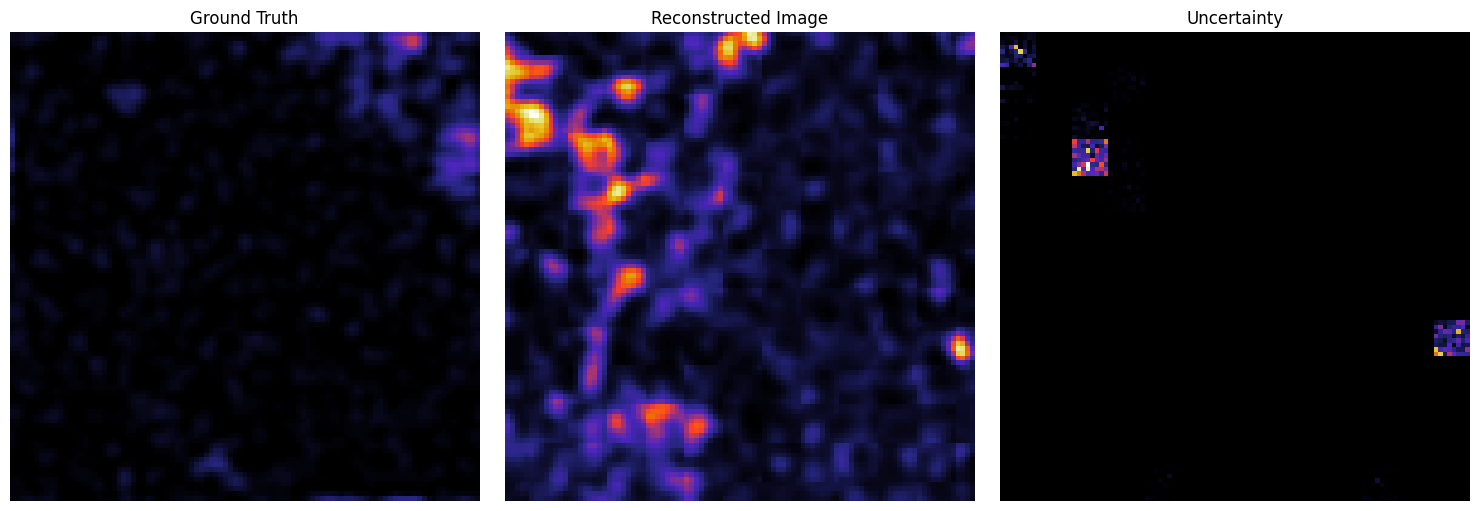

In [70]:
import matplotlib.pyplot as plt

def plot_reconstructed_image_with_uncertainty_and_ground_truth(
    reconstructed_img, 
    uncertainty, 
    ground_truth, 
    channel_idx
):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(ground_truth[channel_idx], cmap='CMRmap', vmin=0, vmax=1)
    axes[0].set_title('Ground Truth')
    axes[0].axis('off')
    
    axes[1].imshow(reconstructed_img[channel_idx], cmap='CMRmap')
    axes[1].set_title('Reconstructed Image')
    axes[1].axis('off')
    
    uncertainty_min = uncertainty[channel_idx].min()
    uncertainty_max = uncertainty[channel_idx].max()
    axes[2].imshow(uncertainty[channel_idx], cmap='CMRmap', vmin=uncertainty_min, vmax=uncertainty_max)
    axes[2].set_title('Uncertainty')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

transform = 'r90_f'
reconstructed_img, uncertainty = output_reconstruction(el, 16, transform)


plot_reconstructed_image_with_uncertainty_and_ground_truth(
    reconstructed_img, 
    uncertainty, 
    crop, 
    channel_idx=3
)

In [9]:
# Import necessary modules for PLGraphAE
import os
import rootutils

rootutils.setup_root(os.getcwd(), indicator=".project-root", pythonpath=True)

import torch
import lightning as L
from omegaconf import DictConfig, OmegaConf
from src.models.pigvae_auto_module import PLGraphAE
from src.models.components.modules import GraphAE
from src.models.components.schedulers import TemperatureScheduler, EntropyWeightScheduler
from src.models.components.model import Critic
from src.data.components.graphs_datamodules import DenseGraphBatch


In [10]:
# Configuration for the PLGraphAE model based on the saved checkpoint
model_config = {
    "input_size": 128,
    "num_heads": 4,
    "num_layers": 4,
    "emb_dim": 512,
    "vae": True,
    "dropout": 0.1,
    "encoder": {
        "graph_encoder_hidden_dim": 128,
        "num_node_features": 512,
        "num_edge_features": 0,
        "graph_encoder_num_heads": 4,
        "graph_encoder_ppf_hidden_dim": 512,  # 128 * 4
        "graph_encoder_num_layers": 4,
        "emb_dim": 512,
        "dropout": 0.1,
        "grid_size": 13,
        "project": True
    },
    "decoder": {
        "graph_decoder_hidden_dim": 128,
        "graph_decoder_pos_emb_dim": 128,
        "graph_decoder_num_heads": 4,
        "graph_decoder_ppf_hidden_dim": 512,  # 128 * 4
        "graph_decoder_num_layers": 4,
        "dropout": 0.1,
        "head_dim": 32,  # 128 / 4
        "num_embeddings": 786,
        "num_node_features": 512,
        "num_edge_features": 0,
        "project": True
    },
    "bottle_neck_encoder": {
        "graph_encoder_hidden_dim": 128,
        "emb_dim": 512,
        "vae": True,
        "activation": "silu",
        "num_permutations": 8
    },
    "bottle_neck_decoder": {
        "emb_dim": 512,
        "graph_decoder_hidden_dim": 128
    },
    "property_predictor": {
        "emb_dim": 512,
        "property_predictor_hidden_dim": 128,
        "num_properties": 1
    },
    "permuter": {
        "graph_decoder_hidden_dim": 128,
        "graph_decoder_num_heads": 4,
        "graph_decoder_ppf_hidden_dim": 512,  # 128 * 4
        "dropout": 0.1,
        "num_permutations": 8,
        "grid_size": 13,
        "break_symmetry_scale": 0.05,
        "emb_dim": 512,
        "turn_off": False,
        "use_ce": False,
        "use_context": False,
        "head_dim": 32,  # 128 / 4
        "n_components": 2
    }
}

# Temperature and entropy weight scheduler configs
temp_scheduler_config = {
    "initial_tau": 0.75,
    "final_tau": 0.15,
    "num_epochs": 500,
    "start_epoch": 1
}

entropy_scheduler_config = {
    "initial_weight": 0.3,
    "final_weight": 0.03,
    "mode": "exponential",
    "num_epochs": 500,
    "start_epoch": 1
}

# Critic config
critic_config = {
    "kld_loss_scale": 1.0e-05,
    "perm_loss_scale": 0.8,
    "contrastive_loss_scale": 0.01,
    "temperature": 0.07,
    "num_aug_per_sample": 8,
    "vae": True
}


In [11]:
# Convert dictionaries to OmegaConf DictConfig objects
print("Converting configurations to DictConfig...")
model_config_omegaconf = OmegaConf.create(model_config)
temp_scheduler_config_omegaconf = OmegaConf.create(temp_scheduler_config)
entropy_scheduler_config_omegaconf = OmegaConf.create(entropy_scheduler_config)
critic_config_omegaconf = OmegaConf.create(critic_config)

# Instantiate the model components
print("Creating GraphAE...")
graph_ae = GraphAE(hparams=model_config_omegaconf)

print("Creating schedulers...")
temperature_scheduler = TemperatureScheduler(hparams=temp_scheduler_config_omegaconf)
entropy_weight_scheduler = EntropyWeightScheduler(hparams=entropy_scheduler_config_omegaconf)

print("Creating critic...")
critic = Critic(hparams=critic_config_omegaconf)

print("Creating optimizer (dummy for loading)...")
# Create a dummy optimizer for loading (it will be overridden by the checkpoint)
optimizer = torch.optim.Adam(graph_ae.parameters(), lr=0.0001)

print("Creating scheduler (dummy for loading)...")
# Create a dummy scheduler for loading
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1)

print("All components created successfully!")


Converting configurations to DictConfig...
Creating GraphAE...
Creating schedulers...
Creating critic...
Creating optimizer (dummy for loading)...
Creating scheduler (dummy for loading)...
All components created successfully!


In [ ]:
# Create the PLGraphAE model
print("Creating PLGraphAE model...")
model = PLGraphAE(
    graph_ae=graph_ae,
    critic=critic,
    temperature_scheduler=temperature_scheduler,
    entropy_weight_scheduler=entropy_weight_scheduler,
    optimizer=optimizer,
    scheduler=scheduler,
    compile=False
)

print("PLGraphAE model created successfully!")


Creating PLGraphAE model...
PLGraphAE model created successfully!


/home/tnocon/master_thesis/IMMUVIS-PIGVAE/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'critic' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['critic'])`.
/home/tnocon/master_thesis/IMMUVIS-PIGVAE/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'temperature_scheduler' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['temperature_scheduler'])`.
/home/tnocon/master_thesis/IMMUVIS-PIGVAE/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'entropy_weight_scheduler' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['entropy_weight_scheduler'])`.
/home/tnocon/master_thesis/IMMUVIS

In [13]:
# Load the checkpoint
checkpoint_path = "/raid/tnocon/logs/train/runs/2025-09-18_10-12-53/checkpoints/last.ckpt"

print(f"Loading checkpoint from: {checkpoint_path}")
print("This may take a moment...")

# Load the checkpoint with weights_only=False since this is a Lightning checkpoint
# that contains more than just weights (it's safe since this is our own trained model)
checkpoint = torch.load(checkpoint_path, map_location='cuda:0', weights_only=False)
print("Checkpoint loaded successfully!")

# Load the state dict into the model
model.load_state_dict(checkpoint['state_dict'])
print("Model weights loaded successfully!")

# Set model to evaluation mode
model.eval()
print("Model is ready for inference!")


Loading checkpoint from: /raid/tnocon/logs/train/runs/2025-09-18_10-12-53/checkpoints/last.ckpt
This may take a moment...
Checkpoint loaded successfully!
Model weights loaded successfully!
Model is ready for inference!


In [14]:
# Optional: Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"Model moved to device: {device}")

# Display model summary
print("\nModel loaded successfully!")
print(f"- Checkpoint epoch: {checkpoint.get('epoch', 'Unknown')}")
print(f"- Global step: {checkpoint.get('global_step', 'Unknown')}")
print(f"- Model device: {next(model.parameters()).device}")
print(f"- Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"- Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Model moved to device: cuda

Model loaded successfully!
- Checkpoint epoch: 499
- Global step: 112500
- Model device: cuda:0
- Model parameters: 1,395,880
- Trainable parameters: 1,395,848


In [15]:
# Example usage: How to use the loaded model for inference
# The model expects a DenseGraphBatch as input
# You can now use the model like this:

print("Model is ready for inference!")
print("\nExample usage:")
print("# For inference:")
print("# graph_emb, graph_pred, soft_probs, perm, mu, logvar = model(graph_batch, training=False, tau=1.0)")
print("\n# For training mode:")
print("# graph_emb, graph_pred, soft_probs, perm, mu, logvar = model(graph_batch, training=True, tau=0.5)")

print(f"\nThe model expects:")
print(f"- Input: DenseGraphBatch object")
print(f"- training: bool (True for training, False for inference)")
print(f"- tau: float (temperature parameter, typically 1.0 for inference)")

print(f"\nModel outputs:")
print(f"- graph_emb: Graph embeddings")
print(f"- graph_pred: Reconstructed graph")
print(f"- soft_probs: Soft permutation probabilities")
print(f"- perm: Permutation matrices")
print(f"- mu: VAE mean")
print(f"- logvar: VAE log variance")


Model is ready for inference!

Example usage:
# For inference:
# graph_emb, graph_pred, soft_probs, perm, mu, logvar = model(graph_batch, training=False, tau=1.0)

# For training mode:
# graph_emb, graph_pred, soft_probs, perm, mu, logvar = model(graph_batch, training=True, tau=0.5)

The model expects:
- Input: DenseGraphBatch object
- training: bool (True for training, False for inference)
- tau: float (temperature parameter, typically 1.0 for inference)

Model outputs:
- graph_emb: Graph embeddings
- graph_pred: Reconstructed graph
- soft_probs: Soft permutation probabilities
- perm: Permutation matrices
- mu: VAE mean
- logvar: VAE log variance


In [16]:
from src.models.components.plot import restore_tensor
import matplotlib.pyplot as plt

base_transforms = IMCBaseDictTransform()

aug_transforms_train = gd.PatchAugmentations(
    prob=1.0,
    size=13,
    patch_size=1,
)

aug_transforms_val = gd.PatchAugmentations(
    prob=1.0,
    size=13,
    patch_size=1,
    is_validation=True,
)

dual_transforms_train = gd.DualOutputTransform(base_transforms, aug_transforms_train)

dual_transforms_val = gd.DualOutputTransform(base_transforms, aug_transforms_val)

train_path = Path("/raid/tnocon/data") / 'IMC' / 'train.h5'
test_path = Path("/raid/tnocon/data") / 'IMC' / 'test.h5'
trainset = PickleDataset(train_path, transform=dual_transforms_train)
testset = PickleDataset(test_path, transform=dual_transforms_val)
train_ratio, val_ratio, test_ratio, leftover_ratio = [3600, 1044, 0, 0]
size_testset = len(testset)
size_trainset = len(trainset)
data_train, _ = random_split(
    dataset=trainset,
    lengths=[train_ratio, size_trainset - train_ratio],
    generator=torch.Generator().manual_seed(42),
)
# dataset = ConcatDataset(datasets=[trainset, testset])
# data_val, data_test, _ = random_split(
#     dataset=testset,
#     lengths=[val_ratio, test_ratio, size_testset - val_ratio - test_ratio],
#     generator=torch.Generator().manual_seed(42),
# )

val_len = val_ratio
test_len = size_testset - val_ratio  # since test_ratio=0

indices = torch.arange(size_testset)  # ordered indices
data_val = torch.utils.data.Subset(testset, indices[:val_len])
data_test = torch.utils.data.Subset(testset, indices[val_len:])

train_dataset = gd.GridGraphDataset(grid_size=13, dataset=data_train, channels=[0])
val_dataset = gd.GridGraphDataset(grid_size=13, dataset=data_val, channels=[0])

train_loader = gd.DenseGraphDataLoader(
    dataset=train_dataset,
    batch_size=8,
    num_workers=7,
    pin_memory=False,
    persistent_workers=7 > 0,
)

val_loader = gd.DenseGraphDataLoader(
    dataset=val_dataset,
    batch_size=8,
    num_workers=7,
    pin_memory=False,
    persistent_workers=7 > 0,
)

In [17]:
for el in val_loader:
    break

In [18]:
el = el.to('cuda:0')

In [19]:
model.eval()
with torch.no_grad():
    graph_emb, graph_pred, soft_probs, perm, mu, logvar = model(el, training=False, tau=1.0)

In [20]:
predictions = graph_pred.node_features
# argsort = el.argsort_augmented_features

tensor([[[-4.5677e-01, -3.4136e-01, -2.9460e-01,  ..., -2.5559e-01,
          -3.0735e-01, -4.2399e-01],
         [-3.4364e-01, -1.5516e-01, -8.6310e-02,  ..., -5.9814e-02,
          -1.1232e-01, -3.0224e-01],
         [-2.9084e-01, -9.7958e-02, -3.5164e-02,  ..., -6.5025e-03,
          -5.9696e-02, -2.4992e-01],
         ...,
         [-2.5908e-01, -7.3155e-02, -2.9668e-03,  ..., -2.6878e-03,
          -4.9733e-02, -2.3788e-01],
         [-3.0901e-01, -1.2163e-01, -5.8169e-02,  ..., -5.9543e-02,
          -1.0970e-01, -2.8693e-01],
         [-4.4080e-01, -3.1140e-01, -2.6331e-01,  ..., -2.6428e-01,
          -2.9723e-01, -4.1891e-01]],

        [[-2.2019e-01, -9.2746e-02, -5.5090e-02,  ...,  3.4745e-02,
          -2.4588e-03, -1.7304e-01],
         [-8.5673e-02,  8.1046e-02,  1.3661e-01,  ...,  2.6638e-01,
           2.2409e-01, -1.6490e-03],
         [-3.8724e-02,  1.3669e-01,  2.0526e-01,  ...,  3.2251e-01,
           2.8138e-01,  5.1873e-02],
         ...,
         [ 5.5747e-03,  2

In [19]:
import src.models.components.metrics.recontructions as R

batch_size = predictions.shape[0] // 8
idx_to_show = R.batch_augmented_indices(
    batch_size, num_permutations=8, n_examples=2
)

In [20]:
subset_predictions = predictions[idx_to_show, :, :]

RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [26]:
restore_subset_predictions = torch.stack(
            [img[arg, :] for img, arg in zip(subset_predictions, subset_argsort)], dim=0
        )

In [30]:
subset_predictions.shape

torch.Size([128, 169, 512])

In [ ]:
# (B, N, C) -> (B, H, W, C)
x = subset_predictionss.T.view(128, 13, 13, 512)

In [28]:
x.shape # pierwsze 8 powino byc rekonstrkaj patcha

torch.Size([128, 512, 13, 13])

In [23]:
import matplotlib.pyplot as plt

def plot_reconstructed_image_with_uncertainty_and_ground_truth(
    reconstructed_img, 
    uncertainty, 
    # ground_truth, 
    channel_idx
):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # axes[0].imshow(ground_truth[channel_idx], cmap='CMRmap', vmin=0, vmax=1)
    # axes[0].set_title('Ground Truth')
    # axes[0].axis('off')
    
    axes[1].imshow(reconstructed_img[channel_idx], cmap='CMRmap')
    axes[1].set_title('Reconstructed Image')
    axes[1].axis('off')
    
    uncertainty_min = uncertainty[channel_idx].min()
    uncertainty_max = uncertainty[channel_idx].max()
    axes[2].imshow(uncertainty[channel_idx], cmap='CMRmap', vmin=uncertainty_min, vmax=uncertainty_max)
    axes[2].set_title('Uncertainty')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

In [42]:
indices = torch.tensor([i for i in range(decoder_config["num_channels"])]).unsqueeze(0).to('cuda:0')
reconstructed_img, logvar = decoder(predictions[43].T.view(512, 13, 13).unsqueeze(0), indices).unbind(dim=-1)
reconstructed_img = reconstructed_img[:, :, 3:-4, 3:-4]
reconstructed_img = torch.sigmoid(reconstructed_img)

reconstructed_img = reconstructed_img.cpu().detach().numpy()[0]
uncertainty = torch.exp(logvar).cpu().detach().numpy()[0]

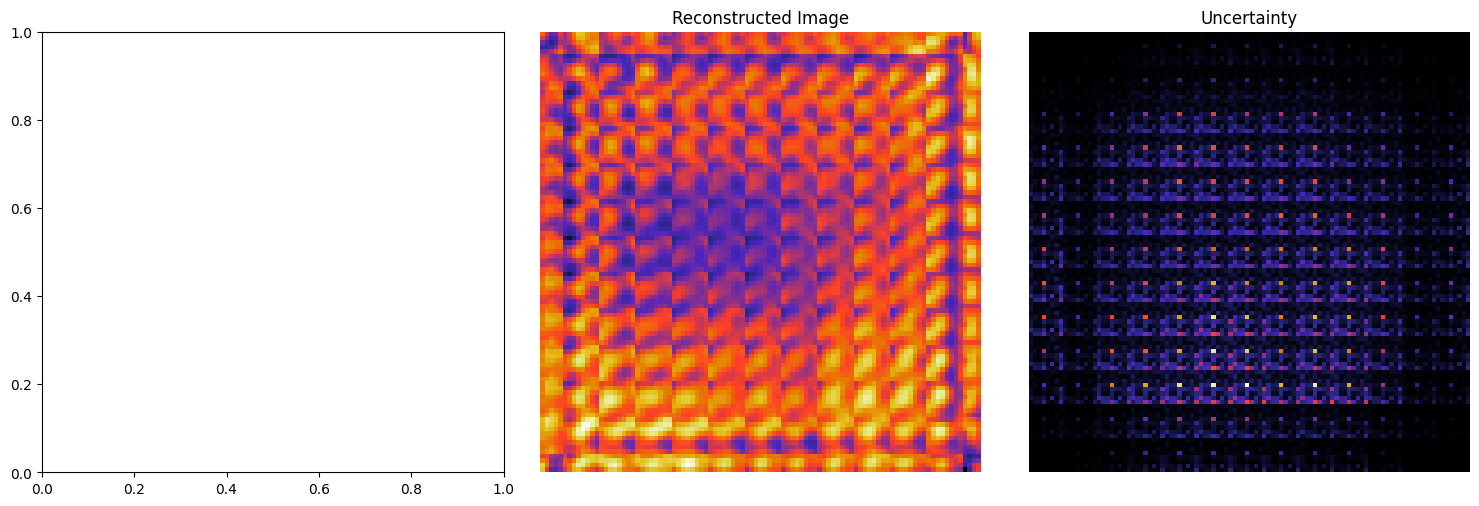

In [44]:
plot_reconstructed_image_with_uncertainty_and_ground_truth(
    reconstructed_img, 
    uncertainty, 
    channel_idx=24
)

[<Figure size 2000x1000 with 33 Axes>, <Figure size 2000x1000 with 33 Axes>]

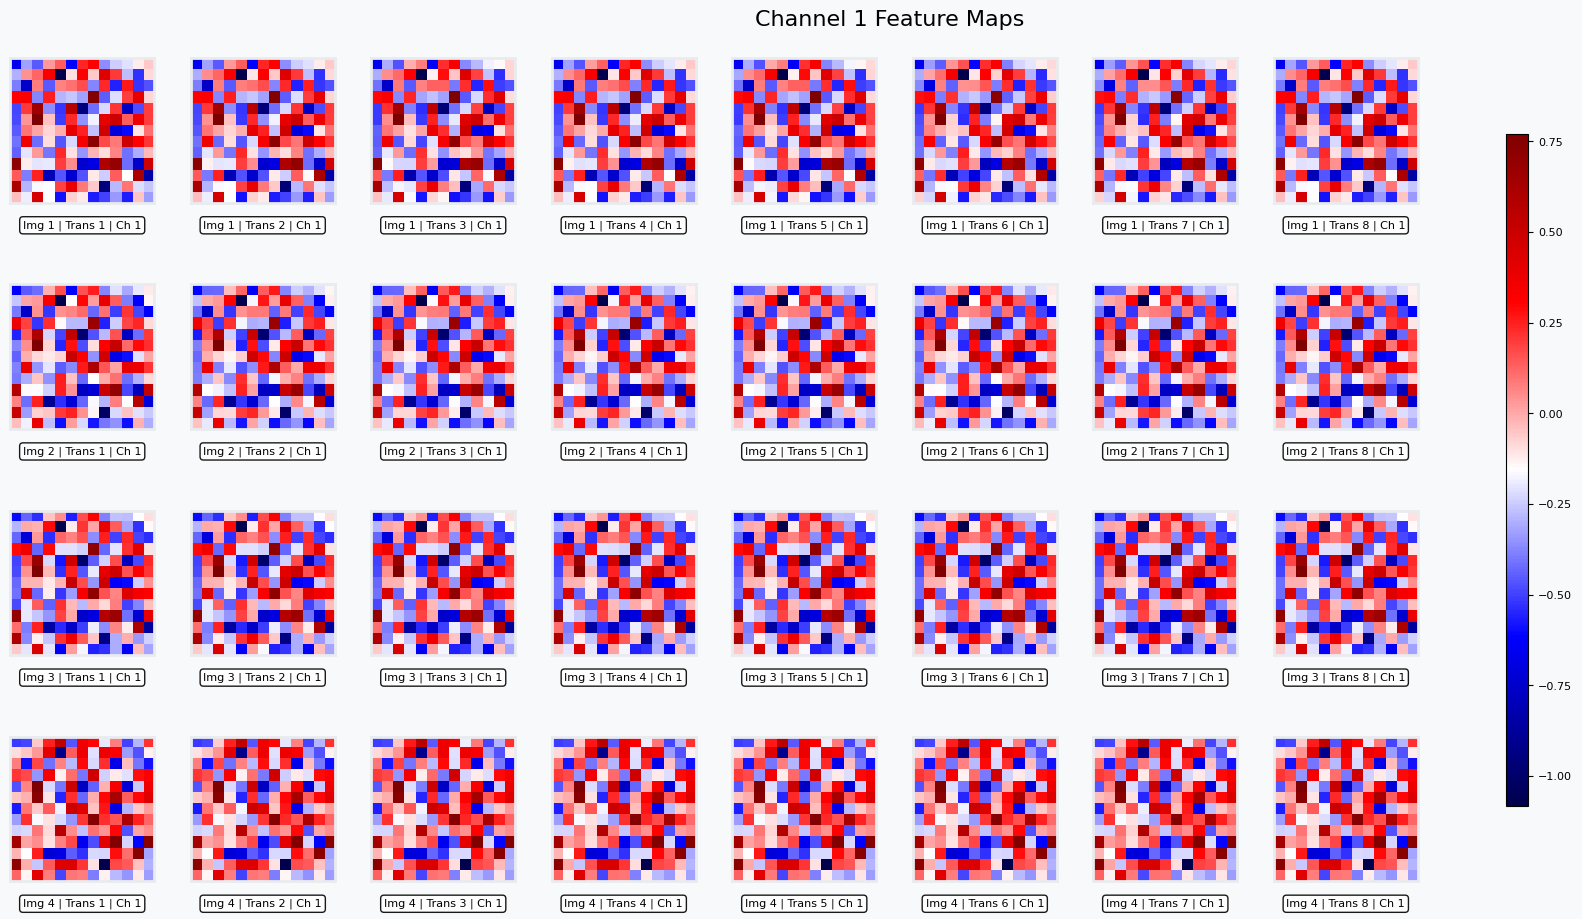

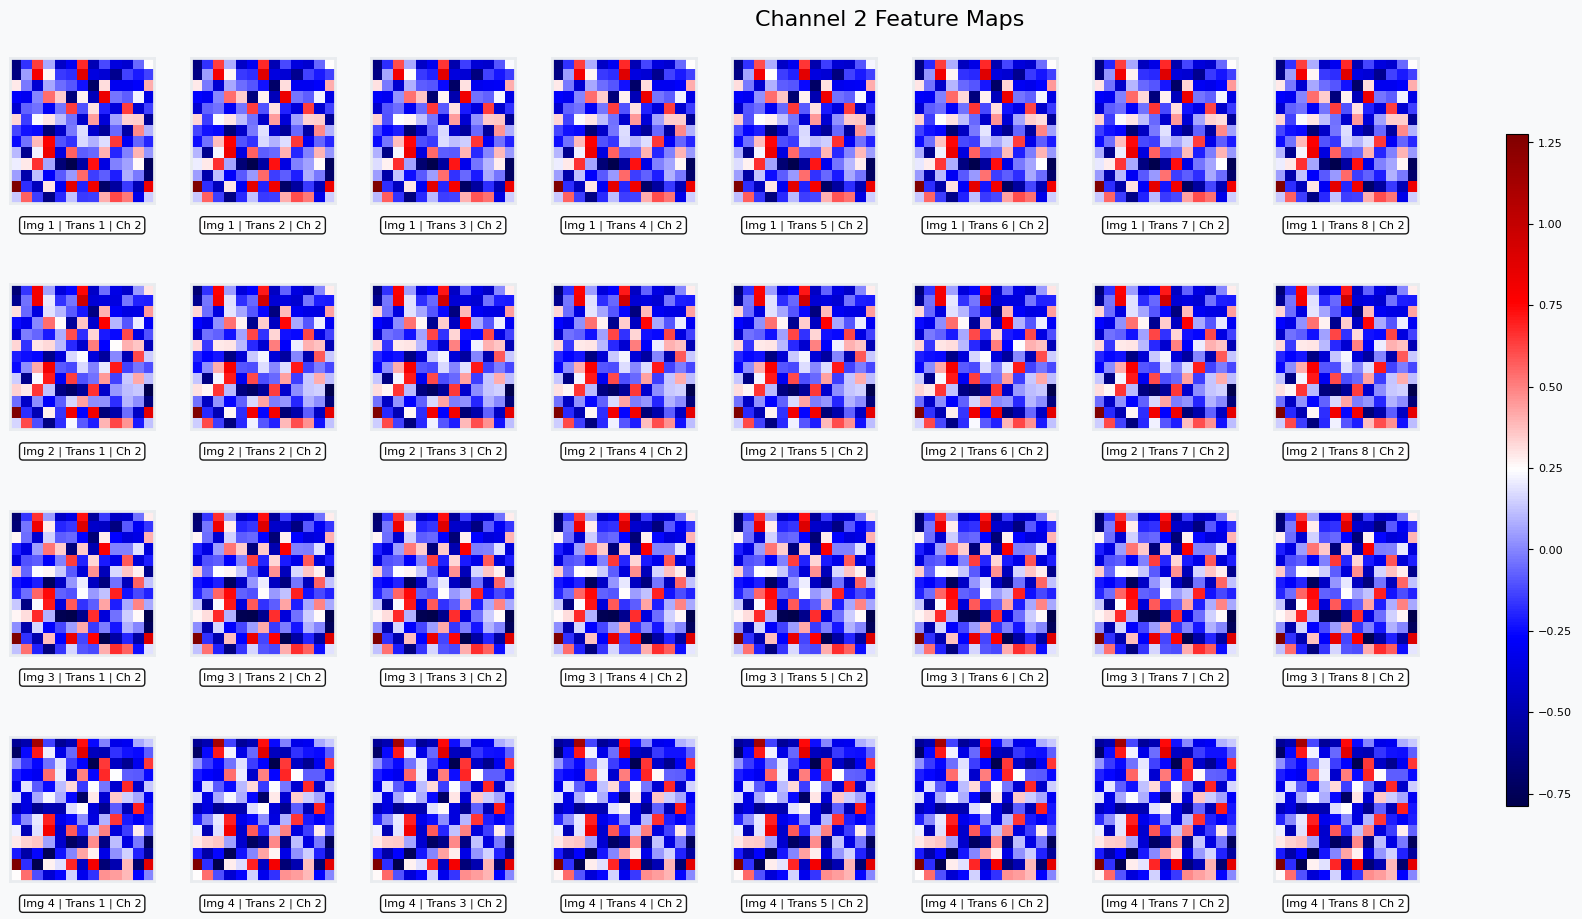

In [40]:
import src.models.components.plot as pL
pL.plot_feature_map(restore_subset_predictions.detach().cpu().squeeze(), 16)

[<Figure size 2000x1000 with 33 Axes>, <Figure size 2000x1000 with 33 Axes>]

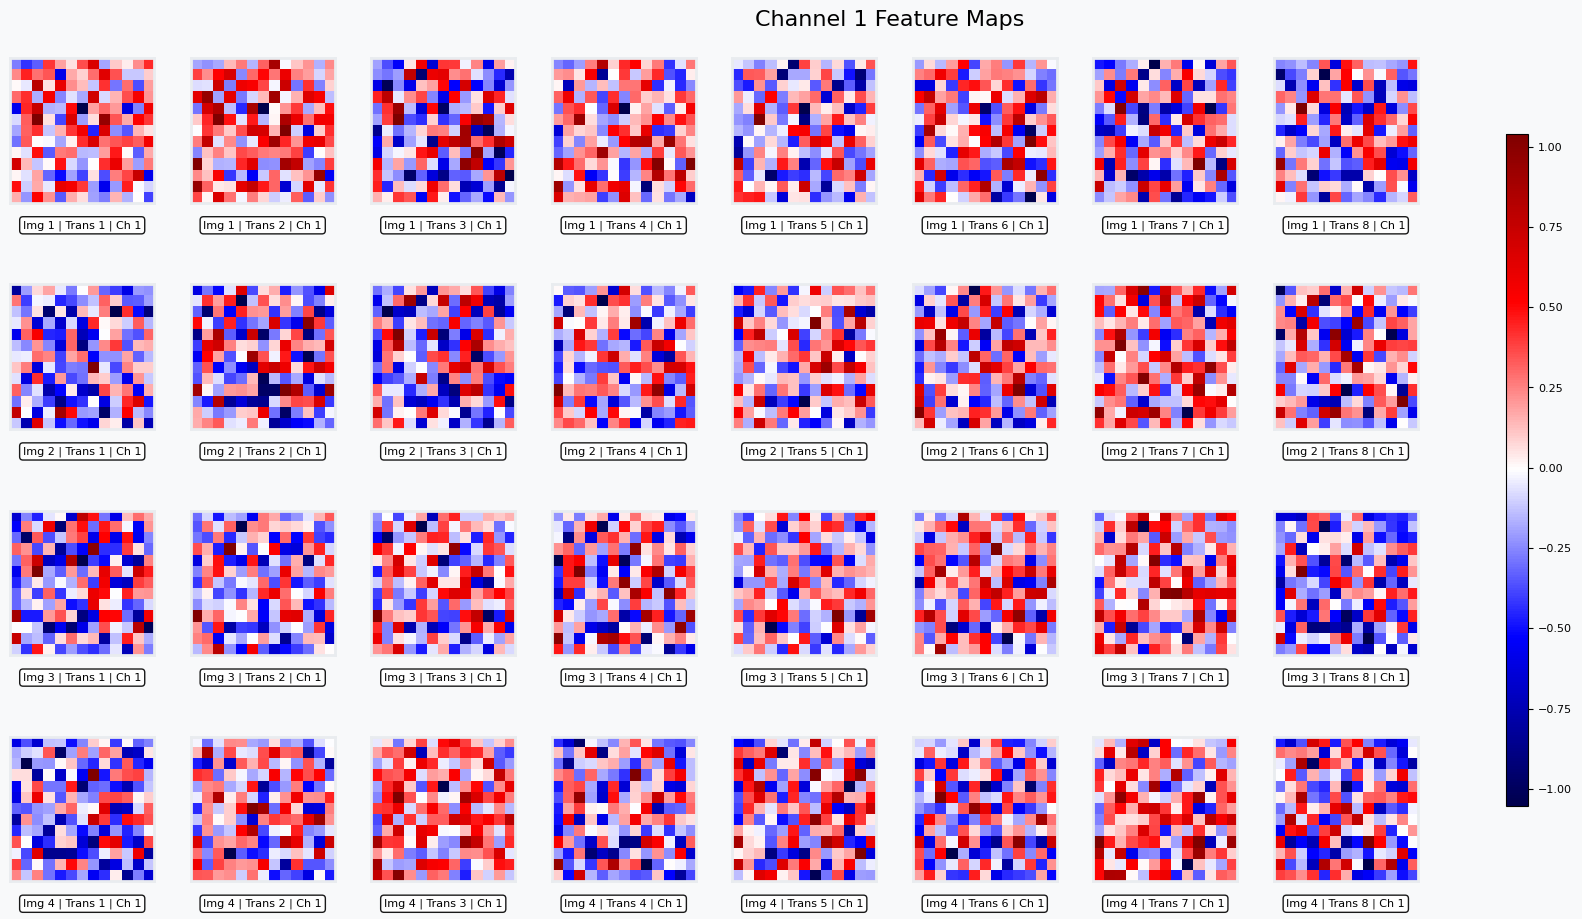

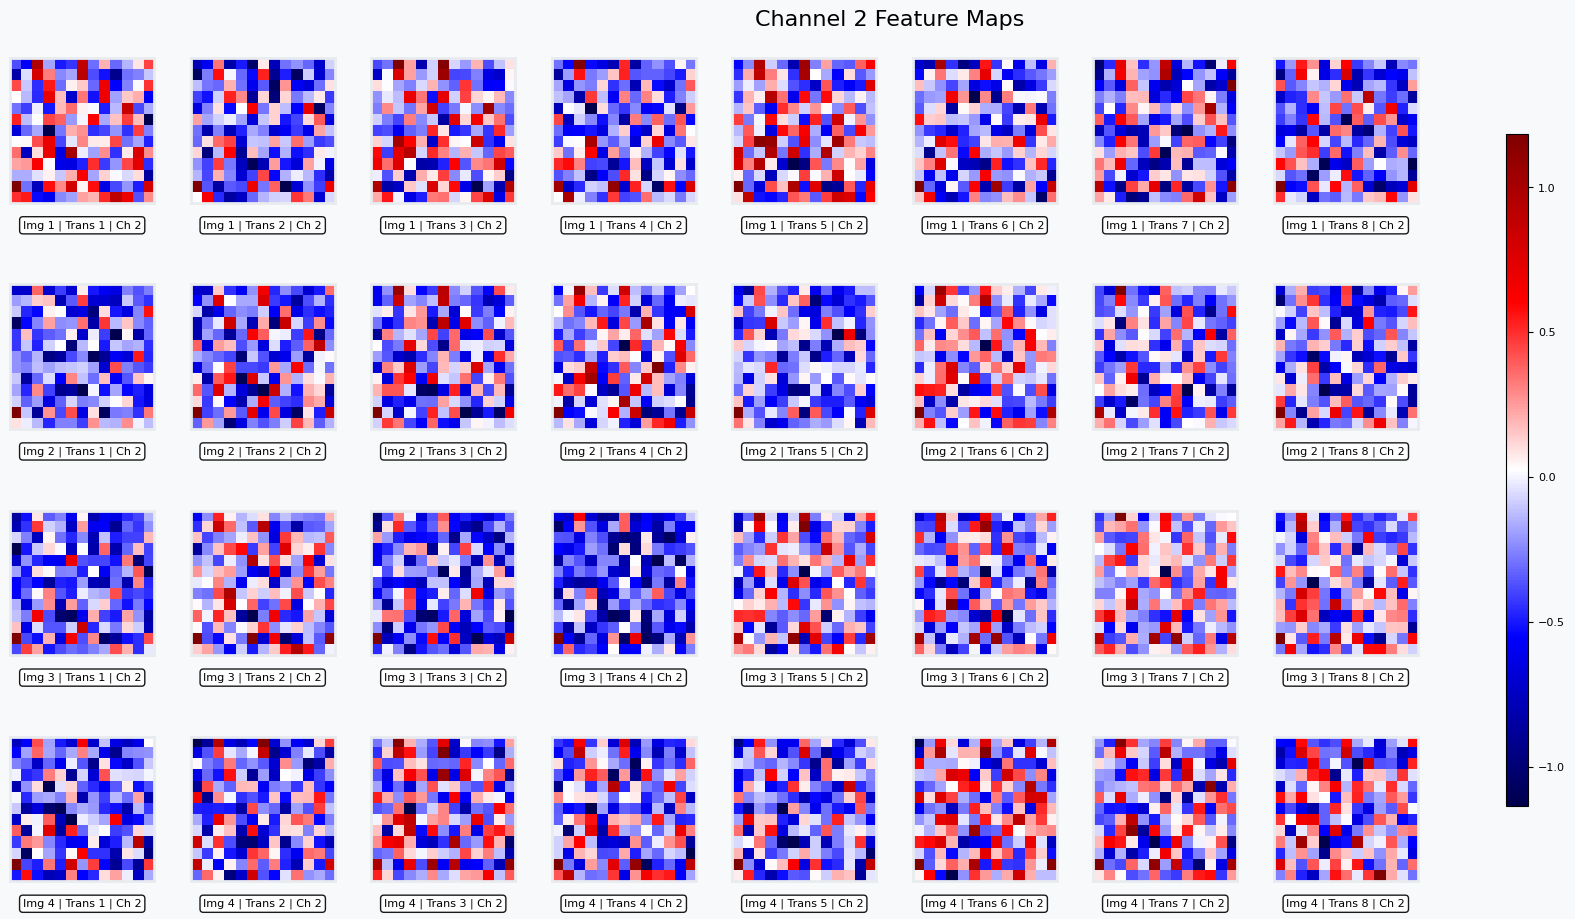

In [46]:
pL.plot_feature_map(el.node_features.detach().cpu(), 16)

[<Figure size 2000x1000 with 33 Axes>, <Figure size 2000x1000 with 33 Axes>]

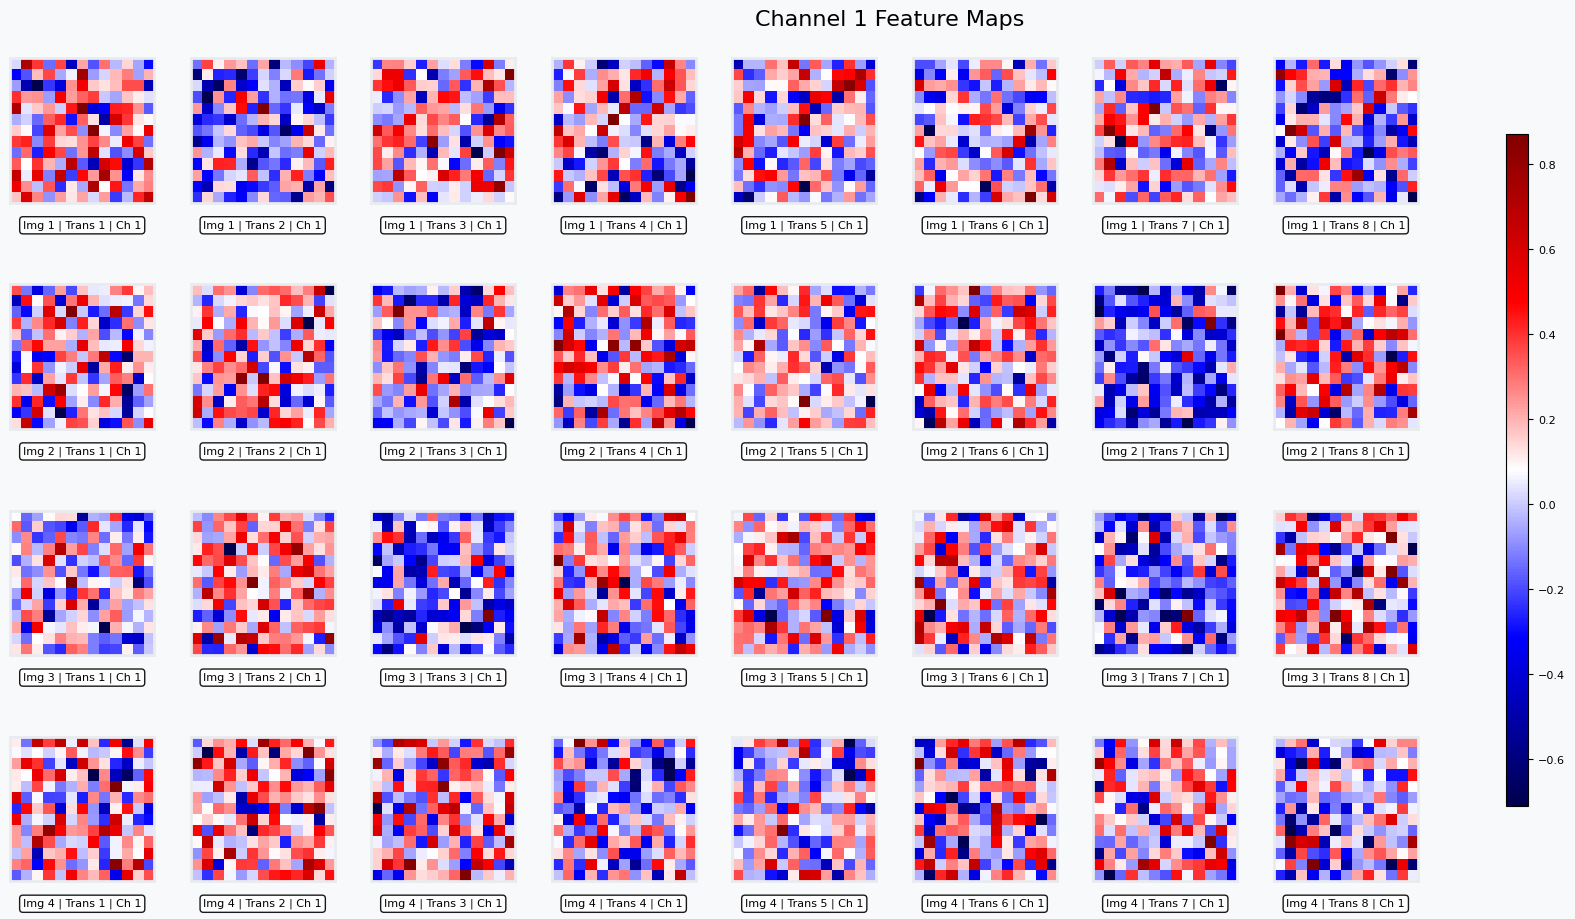

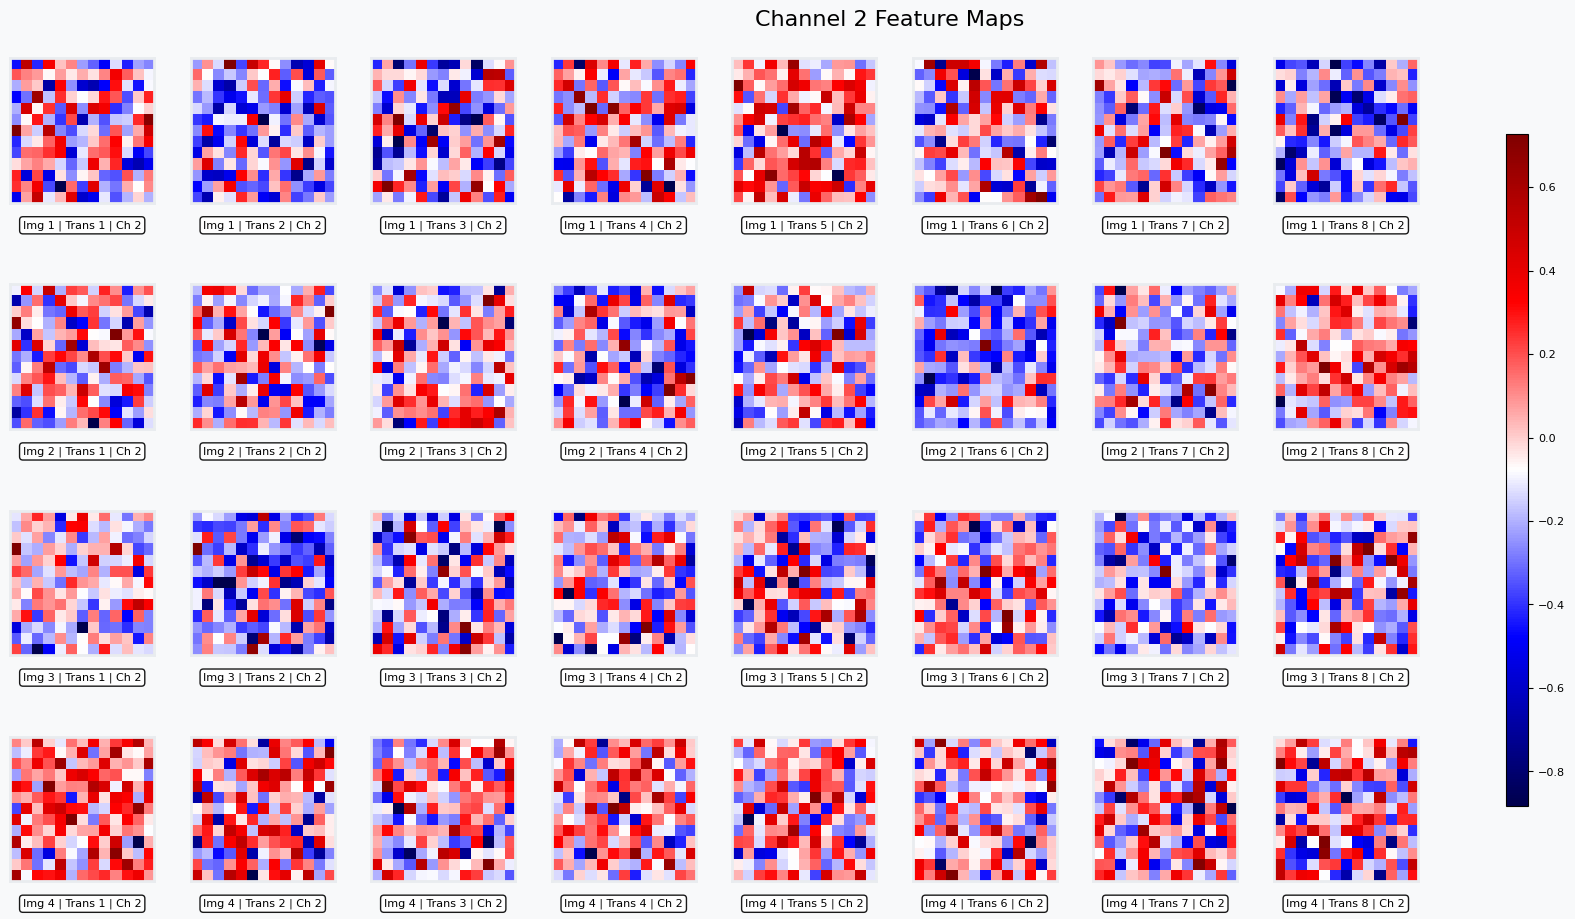

In [48]:
pL.plot_feature_map(restore_subset_predictions.detach().cpu().squeeze() -  el.node_features.detach().cpu(), 16)